In [1]:
import numpy as np
import scipy as sp
import scipy.ndimage


def box(img, r):
    """ O(1) box filter
        img - >= 2d image
        r   - radius of box filter
    """
    (rows, cols) = img.shape[:2]
    imDst = np.zeros_like(img)


    tile = [1] * img.ndim
    tile[0] = r
    imCum = np.cumsum(img, 0)
    imDst[0:r+1, :, ...] = imCum[r:2*r+1, :, ...]
    imDst[r+1:rows-r, :, ...] = imCum[2*r+1:rows, :, ...] - imCum[0:rows-2*r-1, :, ...]
    imDst[rows-r:rows, :, ...] = np.tile(imCum[rows-1:rows, :, ...], tile) - imCum[rows-2*r-1:rows-r-1, :, ...]

    tile = [1] * img.ndim
    tile[1] = r
    imCum = np.cumsum(imDst, 1)
    imDst[:, 0:r+1, ...] = imCum[:, r:2*r+1, ...]
    imDst[:, r+1:cols-r, ...] = imCum[:, 2*r+1 : cols, ...] - imCum[:, 0 : cols-2*r-1, ...]
    imDst[:, cols-r: cols, ...] = np.tile(imCum[:, cols-1:cols, ...], tile) - imCum[:, cols-2*r-1 : cols-r-1, ...]

    return imDst

def _gf_color(I, p, r, eps, s=None):
    """ Color guided filter
    I - guide image (rgb)
    p - filtering input (single channel)
    r - window radius
    eps - regularization (roughly, variance of non-edge noise)
    s - subsampling factor for fast guided filter
    """
    fullI = I
    fullP = p
    if s is not None:
        I = sp.ndimage.zoom(fullI, [1/s, 1/s, 1], order=1)
        p = sp.ndimage.zoom(fullP, [1/s, 1/s], order=1)
        r = round(r / s)

    h, w = p.shape[:2]
    N = box(np.ones((h, w)), r)

    mI_r = box(I[:,:,0], r) / N
    mI_g = box(I[:,:,1], r) / N
    mI_b = box(I[:,:,2], r) / N

    mP = box(p, r) / N

    # mean of I * p
    mIp_r = box(I[:,:,0]*p, r) / N
    mIp_g = box(I[:,:,1]*p, r) / N
    mIp_b = box(I[:,:,2]*p, r) / N

    # per-patch covariance of (I, p)
    covIp_r = mIp_r - mI_r * mP
    covIp_g = mIp_g - mI_g * mP
    covIp_b = mIp_b - mI_b * mP

    # symmetric covariance matrix of I in each patch:
    #       rr rg rb
    #       rg gg gb
    #       rb gb bb
    var_I_rr = box(I[:,:,0] * I[:,:,0], r) / N - mI_r * mI_r;
    var_I_rg = box(I[:,:,0] * I[:,:,1], r) / N - mI_r * mI_g;
    var_I_rb = box(I[:,:,0] * I[:,:,2], r) / N - mI_r * mI_b;

    var_I_gg = box(I[:,:,1] * I[:,:,1], r) / N - mI_g * mI_g;
    var_I_gb = box(I[:,:,1] * I[:,:,2], r) / N - mI_g * mI_b;

    var_I_bb = box(I[:,:,2] * I[:,:,2], r) / N - mI_b * mI_b;

    a = np.zeros((h, w, 3))
    for i in range(h):
        for j in range(w):
            sig = np.array([
                [var_I_rr[i,j], var_I_rg[i,j], var_I_rb[i,j]],
                [var_I_rg[i,j], var_I_gg[i,j], var_I_gb[i,j]],
                [var_I_rb[i,j], var_I_gb[i,j], var_I_bb[i,j]]
            ])
            covIp = np.array([covIp_r[i,j], covIp_g[i,j], covIp_b[i,j]])
            a[i,j,:] = np.linalg.solve(sig + eps * np.eye(3), covIp)

    b = mP - a[:,:,0] * mI_r - a[:,:,1] * mI_g - a[:,:,2] * mI_b

    meanA = box(a, r) / N[...,np.newaxis]
    meanB = box(b, r) / N

    if s is not None:
        meanA = sp.ndimage.zoom(meanA, [s, s, 1], order=1)
        meanB = sp.ndimage.zoom(meanB, [s, s], order=1)

    q = np.sum(meanA * fullI, axis=2) + meanB

    return q


def _gf_gray(I, p, r, eps, s=None):
    """ grayscale (fast) guided filter
        I - guide image (1 channel)
        p - filter input (1 channel)
        r - window raidus
        eps - regularization (roughly, allowable variance of non-edge noise)
        s - subsampling factor for fast guided filter
    """
    if s is not None:
        Isub = sp.ndimage.zoom(I, 1/s, order=1)
        Psub = sp.ndimage.zoom(p, 1/s, order=1)
        r = round(r / s)
    else:
        Isub = I
        Psub = p


    (rows, cols) = Isub.shape

    N = box(np.ones([rows, cols]), r)

    meanI = box(Isub, r) / N
    meanP = box(Psub, r) / N
    corrI = box(Isub * Isub, r) / N
    corrIp = box(Isub * Psub, r) / N
    varI = corrI - meanI * meanI
    covIp = corrIp - meanI * meanP


    a = covIp / (varI + eps)
    b = meanP - a * meanI

    meanA = box(a, r) / N
    meanB = box(b, r) / N

    if s is not None:
        meanA = sp.ndimage.zoom(meanA, s, order=1)
        meanB = sp.ndimage.zoom(meanB, s, order=1)

    q = meanA * I + meanB
    return q


def _gf_colorgray(I, p, r, eps, s=None):
    """ automatically choose color or gray guided filter based on I's shape """
    if I.ndim == 2 or I.shape[2] == 1:
        return _gf_gray(I, p, r, eps, s)
    elif I.ndim == 3 and I.shape[2] == 3:
        return _gf_color(I, p, r, eps, s)
    else:
        print("Invalid guide dimensions:", I.shape)


def guided_filter(I, p, r, eps, s=None):
    """ run a guided filter per-channel on filtering input p
        I - guide image (1 or 3 channel)
        p - filter input (n channel)
        r - window raidus
        eps - regularization (roughly, allowable variance of non-edge noise)
        s - subsampling factor for fast guided filter
    """
    if p.ndim == 2:
        p3 = p[:,:,np.newaxis]

    out = np.zeros_like(p3)
    for ch in range(p3.shape[2]):
        out[:,:,ch] = _gf_colorgray(I, p3[:,:,ch], r, eps, s)
    return np.squeeze(out) if p.ndim == 2 else out


def test_gf():
    import imageio
    cat = imageio.imread('cat.bmp').astype(np.float32) / 255
    tulips = imageio.imread('tulips.bmp').astype(np.float32) / 255

    r = 8
    eps = 0.05

    cat_smoothed = guided_filter(cat, cat, r, eps)
    cat_smoothed_s4 = guided_filter(cat, cat, r, eps, s=4)

    imageio.imwrite('cat_smoothed.png', cat_smoothed)
    imageio.imwrite('cat_smoothed_s4.png', cat_smoothed_s4)

    tulips_smoothed4s = np.zeros_like(tulips)
    for i in range(3):
        tulips_smoothed4s[:,:,i] = guided_filter(tulips, tulips[:,:,i], r, eps, s=4)
    imageio.imwrite('tulips_smoothed4s.png', tulips_smoothed4s)

    tulips_smoothed = np.zeros_like(tulips)
    for i in range(3):
        tulips_smoothed[:,:,i] = guided_filter(tulips, tulips[:,:,i], r, eps)
    imageio.imwrite('tulips_smoothed.png', tulips_smoothed)

In [2]:
def New_edger(im, radius=4, eps=0.00001, threshold1=20, threshold2=55):
    
    one = cv2.imread(im, cv2.IMREAD_GRAYSCALE)
    blurred_image = cv2.equalizeHist(one)
    blurred_image = cv2.GaussianBlur(blurred_image, (5, 5), 5)
    two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    #blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
    #two=guided_filter(blurred_image, blurred_image, radius, eps)
    edges_skinny = cv2.Canny(two, threshold1=threshold1, threshold2=threshold2,apertureSize = 3, L2gradient = 3)
    kernel = np.ones((5, 5), np.uint8)
    dilated_edges = cv2.dilate(edges_skinny, kernel, iterations=1)
    contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    edges_worm = cv2.Canny(two, threshold1=20, threshold2=55,apertureSize = 7, L2gradient = 1)
        # Assuming there is at least one contour found
    if contours:
        # Find the largest contour by area
        largest_contour = max(contours, key=cv2.contourArea)

        # Create a mask for the largest contour
        mask = np.zeros_like(edges)
        cv2.drawContours(mask, [largest_contour], -1, color=255, thickness=cv2.FILLED)
        intersected_edges = cv2.bitwise_and(edges_worm, dilated_edges, mask=mask)
        # Count the elements (in this case, just 1 - the largest)
        element_count = 1
    plt.figure()
    print(intersected_edges.shape, intersected_edges.dtype)
    print(largest_contour.shape, largest_contour.dtype)
#    plt.title("edges_worm", fontweight ="bold") 
 #   plt.imshow(one) 
  #  plt.imshow(edges_worm, cmap='hot', alpha=0.5)  
   # plt.figure()

#    plt.title("edges_skinny", fontweight ="bold") 
 #   plt.imshow(one) 
  #  plt.imshow(edges_skinny, cmap='hot', alpha=0.5)  
    plt.figure()

    plt.title("Intersected", fontweight ="bold") 
    plt.imshow(one) 
    plt.imshow(intersected_edges, cmap='hot', alpha=0.5)  
    
def process_meta(raw_images, setup, bpp):
    image_8bit = (raw_images / (2**bpp - 1) * 255).astype(np.uint8)
    gamma = setup.fGamma
    look_up_table = np.array([((i / 255.0) ** (1 / gamma)) * 255 for i in np.arange(0, 256)]).astype('uint8')
    image_gamma_corrected = cv2.LUT(image_8bit, look_up_table)
    return image_gamma_corrected

In [3]:
import numpy as np
import IPython

import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import glob
from sklearn.decomposition import PCA
import matplotlib.patches as patches
from scipy import ndimage
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths
#from subpixel_edges import subpixel_edges
from scipy.ndimage import median_filter
from skimage.filters import median
from skimage.morphology import square
import cv2

In [4]:
import pycine
from pycine.color import color_pipeline, resize
from pycine.raw import read_frames

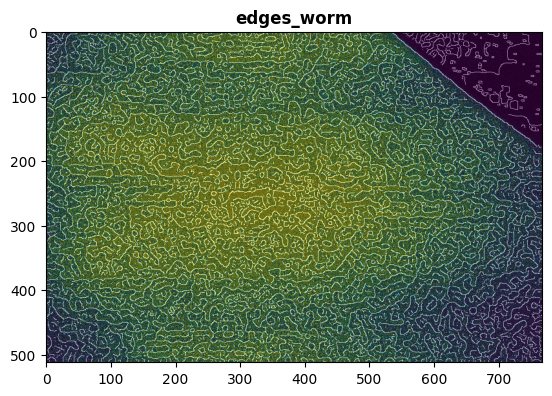

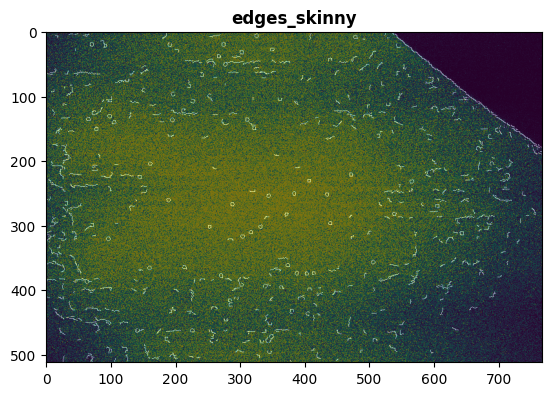

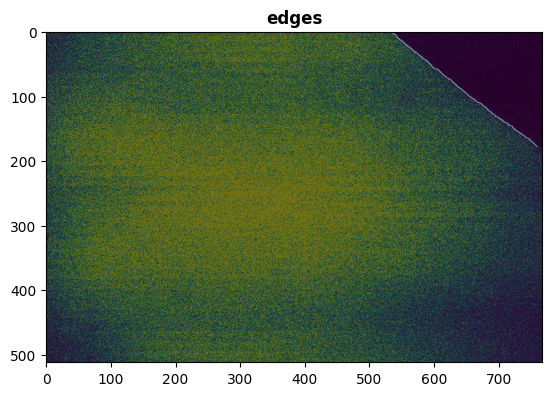

In [5]:
cine_file=r'D:\Lea\240618_PS\60x\Bottoms_view\Analysis\Test1\Test1\CL_1.cine'
start_frame=150
kernel = np.ones((5, 5), np.uint8)
raw_images, setup, bpp = read_frames(cine_file, start_frame=150,count=None)
first_image = next(raw_images, None)
cine_header = pycine.file.read_header(cine_file)  # Make sure this function exists and works correctly
total_frames = len(cine_header["pImage"])
raw_images, setup, bpp = read_frames(cine_file, start_frame=100, count=total_frames-start_frame-1)
#raw_images, setup, bpp = read_frames(cine_file, start_frame=start_frame, count=count)
image_gamma_corrected = process_meta(first_image, setup, bpp)

#plt.figure()
radius=2

image_gamma_corrected = process_meta(first_image, setup, bpp)
#Background
background = cv2.GaussianBlur(image_gamma_corrected, (51, 51), 0)  # Large kernel to remove details
#Subtract the background from the original image
corrected_image = cv2.subtract(image_gamma_corrected, background)
#Normalize contrast using histogram equalization
one = cv2.equalizeHist(image_gamma_corrected)  # Histogram equalization

blurred_image = cv2.GaussianBlur(one, (5, 5), 5)
eps=0.00001
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)
blurred_image = cv2.GaussianBlur(two, (5, 5), 5)
two=guided_filter(blurred_image, blurred_image, radius, eps)

two=guided_filter(blurred_image, blurred_image, radius, eps)
edges_skinny = cv2.Canny(two, threshold1=20, threshold2=25,apertureSize = 3, L2gradient = 3)
kernel = np.ones((5, 5), np.uint8)
dilated_edges = cv2.dilate(edges_skinny, kernel, iterations=1)
contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
edges_worm = cv2.Canny(two, threshold1=20, threshold2=25,apertureSize = 7, L2gradient = 1)
        # Assuming there is at least one contour found
if contours:
        # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

        # Create a mask for the largest contour
    mask = np.zeros_like(edges_worm)
    cv2.drawContours(mask, [largest_contour], -1, color=255, thickness=cv2.FILLED)
    intersected_edges = cv2.bitwise_and(edges_worm, dilated_edges, mask=mask)
        # Count the elements (in this case, just 1 - the largest)
    element_count = 1
    
contours, _ = cv2.findContours(intersected_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
        # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

        # Create a mask for the largest contour
    new = np.zeros_like(intersected_edges)
    cv2.drawContours(new, [largest_contour], -1, color=255, thickness=cv2.FILLED)
    
        # Count the elements (in this case, just 1 - the largest)
    element_count = 1    
    
    
plt.figure()

plt.title("edges_worm", fontweight ="bold") 
plt.imshow(one) 
plt.imshow(edges_worm, cmap='hot', alpha=0.5)  
plt.figure()

plt.title("edges_skinny", fontweight ="bold") 
plt.imshow(one) 
plt.imshow(edges_skinny, cmap='hot', alpha=0.5)  
plt.figure()

plt.title("edges", fontweight ="bold") 
plt.imshow(one) 
plt.imshow(new, cmap='hot', alpha=0.5)  